In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from value import Value
from graph import draw_dot

In [30]:
a = Value(2.0)
b = Value(4.0)

In [31]:
a - b

Value(val = -2.0)

In [32]:
a.exp()

Value(val = 7.38905609893065)

In [33]:
import numpy as np
import matplotlib as plt

In [34]:

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1 * w1'
x2w2 = x2*w2; x2w2.label = 'x2 * w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1 * w1 + x2 * w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

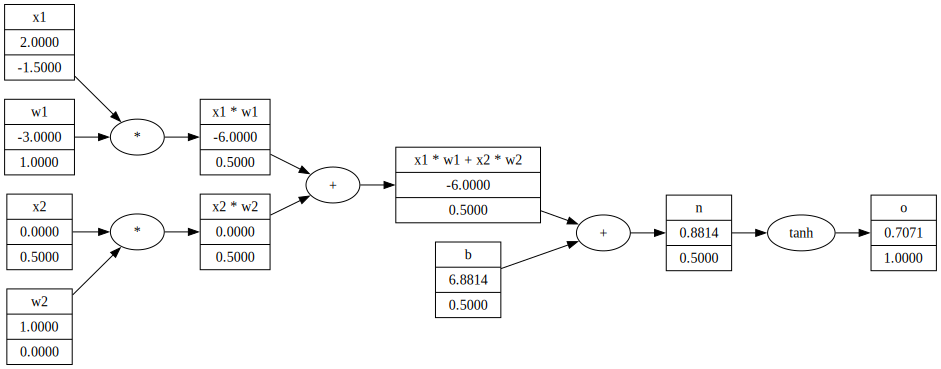

In [35]:
draw_dot(o)

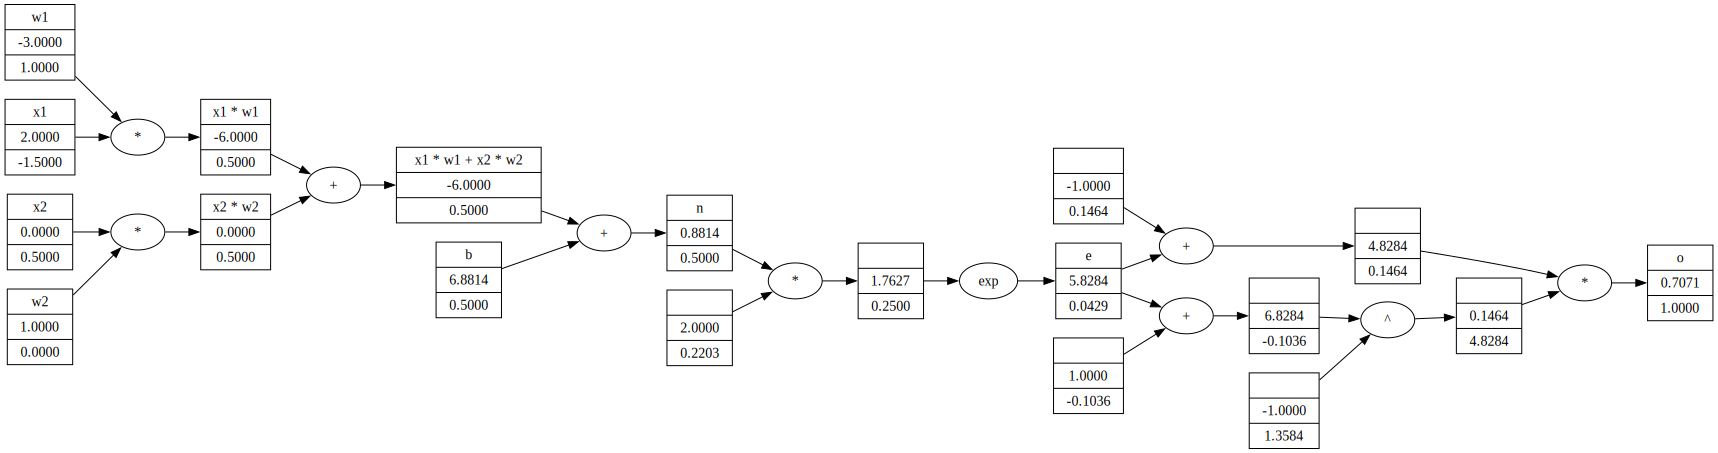

In [36]:

from matplotlib.pyplot import draw


x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1 * w1'
x2w2 = x2*w2; x2w2.label = 'x2 * w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1 * w1 + x2 * w2'

n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1); o.label = 'o'
o.backward()
draw_dot(o)


In [37]:
import torch

In [38]:
x1 = torch.Tensor([2.0]).double()
w1 = torch.Tensor([-3.0]).double()
x2 = torch.Tensor([0.0]).double()
w2 = torch.Tensor([1.0]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

n = x1*w1+x2*w2+b

o = torch.tanh(n)
print(o)

o.backward()

print(f'x2: {x2.grad}')

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
x2: tensor([0.5000], dtype=torch.float64)


In [39]:
from neuron import MLP

In [40]:
x = [2.0, -1.0, 1.5]
n = MLP(3, [4, 4, 1])
output = n(x)

In [41]:
output

Value(val = 0.4824370740037743)

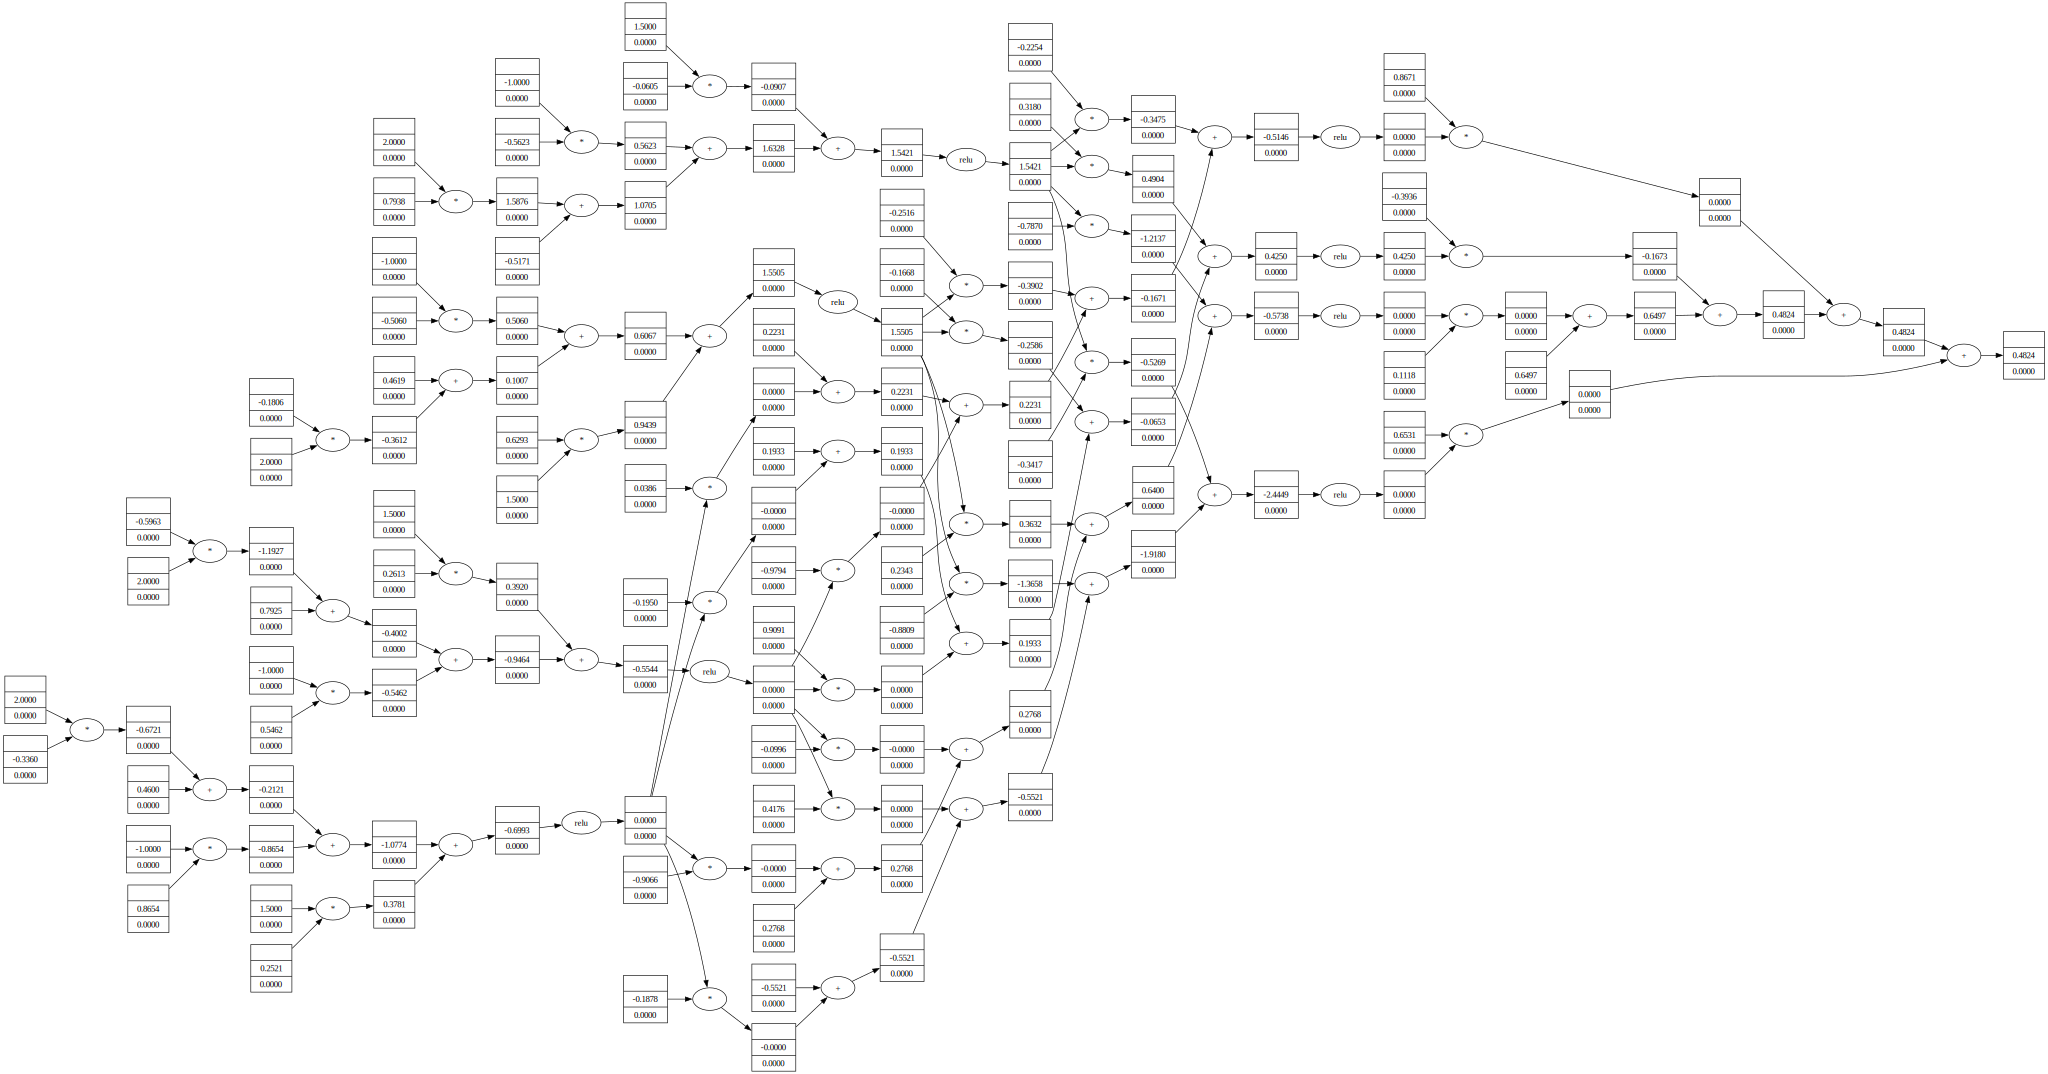

In [42]:
draw_dot(output)

In [43]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [53]:
n = MLP(3, [4, 4, 1])

ypred = [n(x) for x in xs]
ypred

[Value(val = -0.48147588186963775),
 Value(val = 0.05568751653071588),
 Value(val = -0.14708449152085987),
 Value(val = 0.4427121745397646)]

In [45]:
ypred[0] - ys[0]

Value(val = -3.4964899735366757)

In [46]:
loss = sum([(yp - y) ** 2 for y, yp in zip(ys, ypred)])
loss

Value(val = 22.657615990510635)

In [47]:
loss.backward()

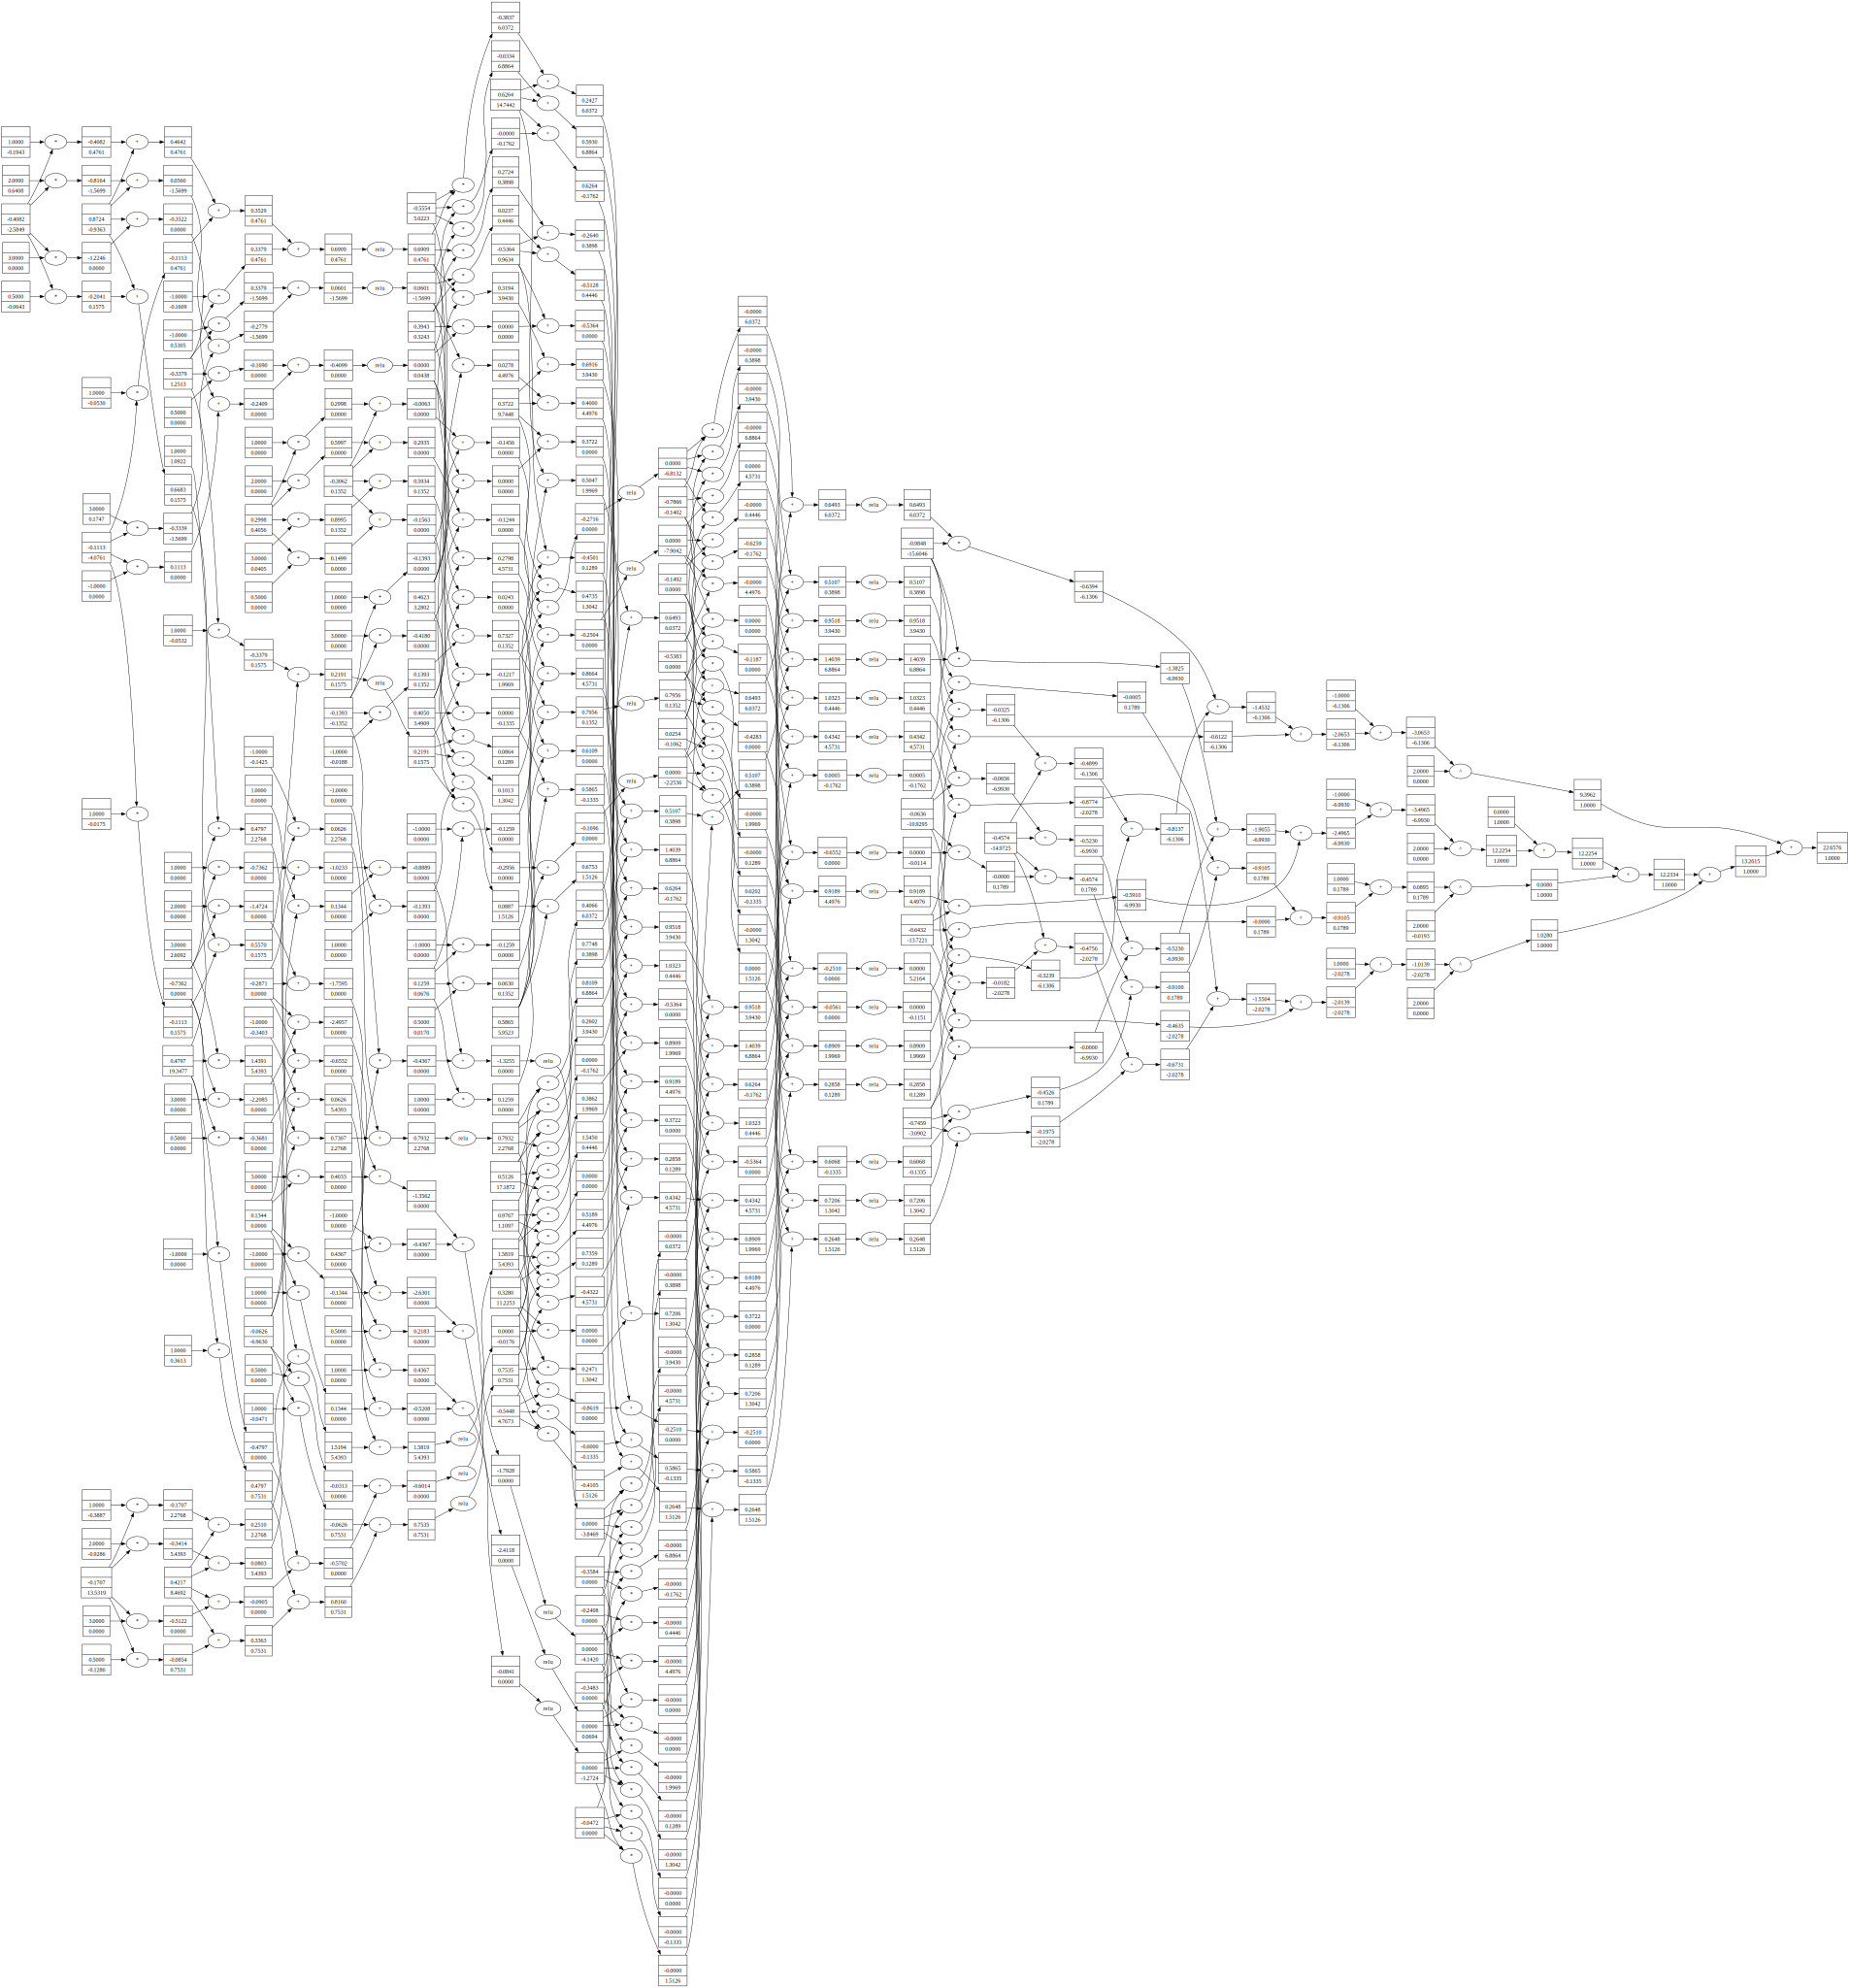

In [48]:
draw_dot(loss)

In [49]:
len(n._params())

41

In [50]:
n._params()

[Value(val = -0.40821235788416854),
 Value(val = -0.11129120143893845),
 Value(val = -0.3379458888533098),
 Value(val = 0.872443828362772),
 Value(val = -0.17071823080615034),
 Value(val = 0.4796987578186127),
 Value(val = -0.06256709984834696),
 Value(val = 0.4216964907633578),
 Value(val = -0.73617504256054),
 Value(val = 0.13443958316310822),
 Value(val = 0.43665570648514374),
 Value(val = -0.28713347638659314),
 Value(val = 0.2998418505586973),
 Value(val = -0.1393174428996662),
 Value(val = 0.12594733152467685),
 Value(val = -0.30617158494282837),
 Value(val = 0.3942978445408176),
 Value(val = 0.9766881727460075),
 Value(val = -0.24077482468144384),
 Value(val = -0.14920342296465727),
 Value(val = -0.5364457576758794),
 Value(val = 0.405045408022499),
 Value(val = -0.5448481940882024),
 Value(val = -0.04715539687254),
 Value(val = 0.025419341489233416),
 Value(val = 0.5865435860353203),
 Value(val = -0.5553768913549162),
 Value(val = 0.5125762538195278),
 Value(val = -0.3584324184

In [54]:
learning_rate = 0.01
steps = 100
for i in range(steps):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yp - y) ** 2 for y, yp in zip(ys, ypred)])

    #backward pass
    for param in n._params():
        param.grad = 0.0

    loss.backward()

    #update
    for param in n._params():
        param.val += -learning_rate * param.grad

    print(i, loss)

0 Value(val = 4.347281506130639)
1 Value(val = 4.0874937686048)
2 Value(val = 3.929341777494216)
3 Value(val = 3.780173644084822)
4 Value(val = 3.6447533194840216)
5 Value(val = 3.510805153516429)
6 Value(val = 3.375650194805976)
7 Value(val = 3.2376670991771963)
8 Value(val = 3.0955689842437355)
9 Value(val = 2.9482896051672207)
10 Value(val = 2.7949897607510943)
11 Value(val = 2.6350987284774425)
12 Value(val = 2.468374986072885)
13 Value(val = 2.29498038634056)
14 Value(val = 2.115560626876559)
15 Value(val = 1.9313204463594498)
16 Value(val = 1.7440763187048227)
17 Value(val = 1.5586468992211244)
18 Value(val = 1.4019232061720242)
19 Value(val = 1.2533699856697869)
20 Value(val = 1.1129471798176631)
21 Value(val = 0.9825686657356121)
22 Value(val = 0.8638268543945964)
23 Value(val = 0.7577713696811692)
24 Value(val = 0.6648081163445376)
25 Value(val = 0.5846931791032913)
26 Value(val = 0.5166149581309852)
27 Value(val = 0.45906245916037824)
28 Value(val = 0.4153442758614233)
29 Val